# Figures  
- Contains figures according to manuscripts

In [1]:
# %matplotlib widget
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
import umap
from sklearn.linear_model import LinearRegression

%reload_ext autoreload
%autoreload 2

from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
import numpy as np
import pandas as pd
import statistics
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from pathlib import Path
import glob

import networkx as nx
import seaborn as sns
from tes.DataUtils import DataUtils
from scipy.stats import mannwhitneyu
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import scipy.stats
from scipy.stats import spearmanr, linregress
import matplotlib.gridspec as gridspec

In [2]:
analyse = AnalysisFunc()
reader = DataRead()
utils = DataUtils()
algo = UmapAlgo()
algo_pf = AlgoParFull()

..\..\data\connectivity_matrix\mb_communities.npz already exists
DataUtils initialized


## Figure 2

In [3]:
# load data
df = reader.data_read_bz2("raw/FN/itr_200.bz2")

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

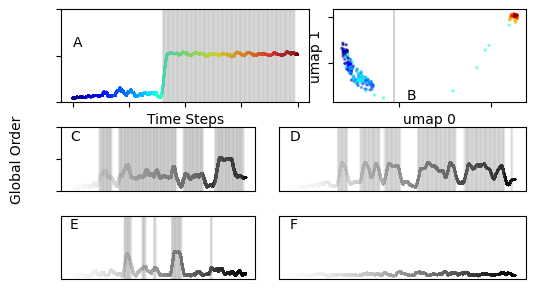

In [4]:
fig = plt.figure(figsize=([6,3.5]))

gs = gridspec.GridSpec(10, 9)
# gs.update(wspace = 1.5, hspace = 0.3)
ax1 = plt.subplot(gs[0:4, 0:5])
# itr 136 of FN
_data = df[39].rolling(800, center=True).mean().ffill().bfill()

cmap = "jet"
with open("../../data/umap_model.pkl", "rb") as f:
	_s, _u = pickle.load(f)
chunk_size = 400
# When you increase or decrease your chunk size, you alter the persistence i.e for how long it stays in sync state
chunks = [
	_data[i : i + chunk_size]
	for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
# create overlapping chunks with 75% overlap

# _s = StandardScaler().fit(chunks)
scaled_data = _s.transform(chunks)
# Train StandardScaler, Z score normalising values

# _u = u.fit(scaled_data)
embedding = _u.transform(scaled_data)
# Fit Umap i.e it converts 400 dimension data to 2 dimensions and we can create boundary

sep = -0.6
plt.subplots_adjust(hspace=6, wspace=0.8)
ax1.scatter(_data.index, _data, c=_data.index, s=0.5, cmap=cmap)
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
	ax1.axvline(l, c="gray", alpha=0.1)
# ax1.set_ylabel("Global Order")
ax1.set_xlabel("Time Steps")
# ax1.set_xlabel('Time Steps')
# ax1.xaxis.set_visible(False)
# ax1.yaxis.set_visible(False)
ax1.set_ylim([0, 1])
ax1.text(0, 0.6, "A")

ax2 = plt.subplot(gs[0:4, 5:9])
# umap
ax2.scatter(
	embedding[:, 0], embedding[:, 1], s=2, c=range(len(chunks)), alpha=0.5, cmap=cmap
)
ax2.set_xlabel("umap 0")
ax2.set_ylabel("umap 1")
ax2.text(0.8, 1, "B")
ax2.axvline(sep, c="k", lw=0.25)
# ax2.xaxis.set_visible(False)
# ax2.yaxis.set_visible(False)
# ax1.set_ylabel('ylabel', labelpad = 0, fontsize = 12)


ax3 = plt.subplot(gs[4:7, 0:4])
# ax2.set_ylabel('ylabel', labelpad = 0, fontsize = 12)
ax3.xaxis.set_visible(False)
# ax3.yaxis.set_visible(False)
_data = df[136].rolling(800, center=True).mean().ffill().bfill()
chunks = [
	_data[i : i + chunk_size]
	for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
sep = -0.6
ax3.scatter(_data.index, _data, c=_data.index, s=1, cmap='Greys')
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
	ax3.axvline(l, c="gray", alpha=0.1)
ax3.set_ylabel('Global Order')
ax3.set_ylim([0, 1])
ax3.text(0, 0.8, "C")

ax4 = plt.subplot(gs[4:7, 4:9], sharex=ax3, sharey=ax3)
# ax3.set_ylabel('ylabel', labelpad = 0, fontsize = 12)
ax4.xaxis.set_visible(False)
ax4.yaxis.set_visible(False)
_data = df[193].rolling(800, center=True).mean().ffill().bfill()
chunks = [
	_data[i : i + chunk_size]
	for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
sep = -0.6
ax4.scatter(_data.index, _data, c=_data.index, s=0.5, cmap='Greys')
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
	ax4.axvline(l, c="gray", alpha=0.1)
ax4.set_ylim([0, 1])
ax4.text(0, 0.8, "D")

ax5 = plt.subplot(gs[7:10, 0:4], sharex=ax3, sharey=ax3)
# ax4.set_ylabel('ylabel', labelpad = 0, fontsize = 12)
ax5.xaxis.set_visible(False)
ax5.yaxis.set_visible(False)
_data = df[145].rolling(800, center=True).mean().ffill().bfill()
chunks = [
	_data[i : i + chunk_size]
	for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
sep = -0.6
ax5.scatter(_data.index, _data, c=_data.index, s=0.5, cmap='Greys')
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
	ax5.axvline(l, c="gray", alpha=0.1)
ax5.set_ylim([0, 1])
ax5.text(0, 0.8, "E")

ax6 = plt.subplot(gs[7:10, 4:9], sharex=ax3, sharey=ax3)
ax6.xaxis.set_visible(False)
ax6.yaxis.set_visible(False)
_data = df[1].rolling(800, center=True).mean().ffill().bfill()
chunks = [
	_data[i : i + chunk_size]
	for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
sep = -0.6
ax6.scatter(_data.index, _data, c=_data.index, s=0.5, cmap='Greys')
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
	ax6.axvline(l, c="gray", alpha=0.1)
ax6.set_ylim([0, 1])
# ax6.set_xlabel("time steps")
ax6.text(0, 0.8, "F")

plt.setp(ax1.get_yticklabels(), visible=False)
plt.setp(ax1.get_xticklabels(), visible=False)


plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)

plt.setp(ax3.get_yticklabels(),visible=False)

fig.align_labels()

fig.set_layout_engine(layout="tight")
# plt.savefig('fig2_final.pdf',format='pdf')
# plt.savefig('../../data/results/figures/fig2_final.svg')
# plt.savefig('../../data/results/figures/fig2_final.pdf',format='pdf')

# Figure 3

#### Read data from folder  
Reference notebook: "Analyse Calculate Final Params.ipynb"


In [26]:
# defining dictionaries for each parameter
# storing both partial and full transition data
# store standard deviation and manWhitney U test values

num_trans = {}
n_p = []
n_p_s = []
n_f = []
n_f_s = []

trans_time = {}
t_p = []
t_p_s = []
t_f = []
t_f_s = []
t_p_mw = []
t_f_mw = []

fp_time = {}
f_p = []
f_p_s = []
f_f = []
f_f_s = []
f_p_mw = []
f_f_mw = []

sync_time = {}
s_p = []
s_p_s = []
s_f = []
s_f_s = []
s_p_mw = []
s_f_mw = []

cov = {}
cov_p = []
cov_p_s = []
cov_f = []
cov_f_s = []
cov_p_mw = []
cov_f_mw = []

# node_label=['PERI','ENTI','ORB','RE','BLA','PIR','MOp','MOs','LHA','MOB','LSc','MRN']
# getting networks in ascending order
network_asc = [
	"fn",
	"mob",
	"lsc",
	"orb",
	"pir",
	"bla",
	"mrn",
	"re",
	"enti",
	"peri",
	"mos",
	"lha",
	"mop",
]
fn_data = reader.data_read_pkl("results/calculate_final_params/final_fn.pkl")

# uses manwhitney u test and stores p value
for nw in network_asc:
	params = reader.data_read_pkl(f"results/calculate_final_params/final_{nw}.pkl")
	# store number of transition
	n_p.append(params[0]["n_part"])
	n_f.append(params[0]["n_full"])
	n_p_s.append(np.sqrt(params[0]["n_part"]))
	n_f_s.append(np.sqrt(params[0]["n_full"]))

	# store transition time
	t_p_s.append(np.std(params[1]["t_t"]) / np.sqrt(len(params[1]["t_t"])))
	t_f_s.append(np.std(params[2]["t_t"]) / np.sqrt(len(params[2]["t_t"])))

	t_p.append(np.mean(params[1]["t_t"]))
	_, mw = mannwhitneyu(fn_data[1]["t_t"], params[1]["t_t"])
	t_p_mw.append(mw)
	t_f.append(np.mean(params[2]["t_t"]))
	_, mw = mannwhitneyu(fn_data[2]["t_t"], params[2]["t_t"])
	t_f_mw.append(mw)

	# store first passage time
	f_p_s.append(np.std(params[1]["fp_t"]) / np.sqrt(len(params[1]["fp_t"])))
	f_f_s.append(np.std(params[2]["fp_t"]) / np.sqrt(len(params[2]["fp_t"])))

	f_p.append(np.mean(params[1]["fp_t"]))
	_, mw = mannwhitneyu(fn_data[1]["fp_t"], params[1]["fp_t"])
	f_p_mw.append(mw)
	f_f.append(np.mean(params[2]["fp_t"]))
	_, mw = mannwhitneyu(fn_data[2]["fp_t"], params[2]["fp_t"])
	f_f_mw.append(mw)

	# Store sync time
	s_p_s.append(np.std(params[1]["s_t"]) / np.sqrt(len(params[1]["s_t"])))
	s_f_s.append(np.std(params[2]["s_t"]) / np.sqrt(len(params[2]["s_t"])))

	s_p.append(np.mean(params[1]["s_t"]))
	_, mw = mannwhitneyu(fn_data[1]["s_t"], params[1]["s_t"])
	s_p_mw.append(mw)
	s_f.append(np.mean(params[2]["s_t"]))
	_, mw = mannwhitneyu(fn_data[2]["s_t"], params[2]["s_t"])
	s_f_mw.append(mw)

	# store coverage
	# removing zero coverage values from partial transitions as they might seep due to very small values
	cov_part=params[1]["cov"]
	cov_part=[x for x in cov_part if x>0]
	cov_p_s.append(np.std(cov_part) / np.sqrt(len(cov_part)))
	cov_f_s.append(np.std(params[2]["cov"]) / np.sqrt(len(params[2]["cov"])))

	cov_p.append(np.mean(cov_part))
	fn_part_cov=[x for x in fn_data[1]["cov"] if x>0]
	_, mw = mannwhitneyu(fn_part_cov, cov_part)
	cov_p_mw.append(mw)
	cov_f.append(np.mean(params[2]["cov"]))
	_, mw = mannwhitneyu(fn_data[2]["cov"], params[2]["cov"])
	cov_f_mw.append(mw)

num_trans = {"n_p": n_p, "n_f": n_f, "n_p_s": n_p_s, "n_f_s": n_f_s}
trans_time = {
	"t_p": t_p,
	"t_f": t_f,
	"t_p_s": t_p_s,
	"t_f_s": t_f_s,
	"t_p_mw": t_p_mw,
	"t_f_mw": t_f_mw,
}
fp_time = {
	"f_p": f_p,
	"f_f": f_f,
	"f_p_s": f_p_s,
	"f_f_s": f_f_s,
	"f_p_mw": f_p_mw,
	"f_f_mw": f_f_mw,
}

sync_time = {
	"s_p": s_p,
	"s_f": s_f,
	"s_p_s": s_p_s,
	"s_f_s": s_f_s,
	"s_p_mw": s_p_mw,
	"s_f_mw": s_f_mw,
}

cov = {
	"cov_p": cov_p,
	"cov_f": cov_f,
	"cov_p_s": cov_p_s,
	"cov_f_s": cov_f_s,
	"cov_p_mw": cov_p_mw,
	"cov_f_mw": cov_f_mw,
}

In [27]:
a = ["num_trans"] * 2
b = ["trans_time"] * 6
c = ["fp_time"] * 6
d = ["sync_time"] * 6
e = ["cov"] * 6
upper_head = a + b + c + d + e

f = ["part", "full"]
g = ["part", "part_s", "part_mw", "full_mw", "full", "full_s"] * 4
lower_head = f + g

header = [upper_head, lower_head]
data = {
	("num_trans", "part"): num_trans["n_p"],
	("num_trans", "full"): num_trans["n_f"],
	("num_trans", "part_s"): num_trans["n_p_s"],
	("num_trans", "full_s"): num_trans["n_f_s"],
	("trans_time", "part"): trans_time["t_p"],
	("trans_time", "part_s"): trans_time["t_p_s"],
	("trans_time", "part_mw"): trans_time["t_p_mw"],
	("trans_time", "full"): trans_time["t_f"],
	("trans_time", "full_s"): trans_time["t_f_s"],
	("trans_time", "full_mw"): trans_time["t_p_mw"],
	("fp_time", "part"): fp_time["f_p"],
	("fp_time", "part_s"): fp_time["f_p_s"],
	("fp_time", "part_mw"): fp_time["f_p_mw"],
	("fp_time", "full"): fp_time["f_f"],
	("fp_time", "full_s"): fp_time["f_f_s"],
	("fp_time", "full_mw"): fp_time["f_p_mw"],
	("sync_time", "part"): sync_time["s_p"],
	("sync_time", "part_s"): sync_time["s_p_s"],
	("sync_time", "part_mw"): sync_time["s_p_mw"],
	("sync_time", "full"): sync_time["s_f"],
	("sync_time", "full_s"): sync_time["s_f_s"],
	("sync_time", "full_mw"): sync_time["s_p_mw"],
	("cov", "part"): cov["cov_p"],
	("cov", "part_s"): cov["cov_p_s"],
	("cov", "part_mw"): cov["cov_p_mw"],
	("cov", "full"): cov["cov_f"],
	("cov", "full_s"): cov["cov_f_s"],
	("cov", "full_mw"): cov["cov_f_mw"],
}

df_data = pd.DataFrame(data, index=network_asc)
df_data

num_trans                            trans_time                      \
          part full     part_s     full_s       part    part_s   part_mw   
fn         187  103  13.674794  10.148892  55.228610  1.074715  1.000000   
mob        132   94  11.489125   9.695360  54.776136  1.089552  0.945461   
lsc        187   97  13.674794   9.848858  55.529947  1.011620  0.865168   
orb        136   94  11.661904   9.695360  53.057721  1.124891  0.157965   
pir        110   67  10.488088   8.185353  54.763636  1.241981  0.522551   
bla        107   51  10.344080   7.141428  54.188318  1.117801  0.985780   
mrn        148   79  12.165525   8.888194  52.996622  0.844252  0.254302   
re         200   92  14.142136   9.591663  54.124500  0.763217  0.836102   
enti       151   57  12.288206   7.549834  53.687417  0.960022  0.481269   
peri        79   47   8.888194   6.855655  50.681013  1.257283  0.010906   
mos        186   42  13.638182   6.480741  52.103763  0.827626  0.040213   
lha        140   55  11.832160   7.416198  52.502143  0.956913  0.041488   
mop        164   72  12.806248   8.485281  51.750000  0.822852  0.036977   

                                     ... sync_time                         \
           full    full_s   full_mw  ...   part_mw        full     full_s   
fn    78.146602  1.312916  1.000000  ...  1.000000  347.435897  35.331097   
mob   83.306383  1.813313  0.945461  ...  0.104380  351.034483  47.294445   
lsc   79.419588  1.289129  0.865168  ...  0.986182  311.785714  68.102203   
orb   82.572340  1.616342  0.157965  ...  0.960917  347.413793  32.158404   
pir   80.195522  1.615760  0.522551  ...  0.040085  399.047619  67.131559   
bla   80.609804  1.689315  0.985780  ...  0.610470  230.625000  28.823784   
mrn   78.601899  1.529340  0.254302  ...  0.791234  407.600000  58.272546   
re    77.778261  1.304602  0.836102  ...  0.504608  487.000000  70.648425   
enti  76.766667  1.499051  0.481269  ...  0.410884  399.722222  54.870038   
peri  79.453191  1.495899  0.010906  ...  0.006671  253.333333  28.349668   
mos   85.559524  2.795582  0.040213  ...  0.324357  268.125000  29.287603   
lha   78.384545  1.645938  0.041488  ...  0.013377  358.000000  83.694683   
mop   78.736111  1.935845  0.036977  ...  0.927616  265.400000  27.489518   

                     cov                                                    
       full_mw      part    part_s   part_mw      full    full_s   full_mw  
fn    1.000000  0.173361  0.007830  1.000000  0.556866  0.006940  1.000000  
mob   0.104380  0.167642  0.008659  0.750962  0.546801  0.007664  0.359165  
lsc   0.986182  0.186380  0.006779  0.348070  0.570075  0.006157  0.201947  
orb   0.960917  0.147165  0.008332  0.024119  0.526395  0.008266  0.009647  
pir   0.040085  0.167115  0.009095  0.737818  0.540389  0.008939  0.137276  
bla   0.610470  0.199997  0.010300  0.107743  0.582879  0.008483  0.028932  
mrn   0.791234  0.172446  0.007612  0.979731  0.518023  0.008323  0.000557  
re    0.504608  0.189600  0.007044  0.183253  0.546913  0.007366  0.338564  
enti  0.410884  0.172499  0.007728  0.775876  0.556293  0.008835  0.951700  
peri  0.006671  0.155180  0.010715  0.159732  0.570277  0.009150  0.288445  
mos   0.324357  0.156893  0.007194  0.120168  0.558530  0.010439  0.890791  
lha   0.013377  0.172548  0.006927  0.761627  0.514550  0.009643  0.000635  
mop   0.927616  0.150628  0.007123  0.041466  0.536189  0.007992  0.068637  

[13 rows x 28 columns]

Extract useful data from dataframe

In [31]:
df_dum=df_data.copy()
num_trans=df_dum[("num_trans","full")].to_list()
trans_time=df_dum[("trans_time","full")].to_list()
cov=df_dum[("cov","full")].to_list()
cov_part=df_dum[("cov","part")].to_list()

Extract network which are significant wrt FN

In [99]:
# find index of significant transition time
t_mw=df_dum[("trans_time","full_mw")]
t_mw_sig=t_mw[t_mw<0.05].index.to_list()
t_mw_l=df_dum[("trans_time","full_mw")].to_list() 
t_m_s=[id for id,x in enumerate(t_mw_l) if x<0.05] #id
# names of significant network
t_m_l=[network_asc[x] for x in t_m_s]


# find significant coverage
cov_mw=df_dum[('cov','full_mw')]
c_mw_sig=cov_mw[cov_mw<0.05].index.to_list()
c_mw_l=df_dum[('cov','full_mw')].to_list() # names of significant networks
c_m_s=[id for id,x in enumerate(c_mw_l) if x<0.05] # id 
c_m_l=[network_asc[x] for x in c_m_s]

Taking those FPT and ST values which corresponds to slope 1 of fitted ST and FPT to exponential
- Data stored in results folder as: 
- ST: '../../results/st_slop1_val_full.pkl' and 
- FPT: '../../results/fpt_slop1_val_full.pkl

FPT correspomding to slope 1  
- mean
- mw

In [83]:
fpt_data=reader.data_read_pkl('results/fpt_slop1_val_full.pkl')
# sort in desired order key
fpt_data={key:fpt_data[key] for key in network_asc}
fpt_mean=[]
fpt_mw=[]
for nw in network_asc:
	fpt_mean.append(np.mean(fpt_data[nw]))
	_,mw=mannwhitneyu(fpt_data['fn'],fpt_data[nw])
	fpt_mw.append(mw)
	
# index of significant nw
f_m_s=[id for id,x in enumerate(fpt_mw) if x<0.05]
# name of significant network
f_m_l=[network_asc[x] for x in f_m_s]

ST corresponding to slope 1

In [88]:
st_data=reader.data_read_pkl('results/st_slop1_val_full.pkl')
# sort in desired order key
st_data={key:st_data[key] for key in network_asc}
st_mean=[]
st_mw=[]
for nw in network_asc:
	st_mean.append(np.mean(st_data[nw]))
	_,mw=mannwhitneyu(st_data['fn'],st_data[nw])
	st_mw.append(mw)
	
# index of significant nw
s_m_s=[id for id,x in enumerate(st_mw) if x<0.05]
# name of significant network
s_m_l=[network_asc[x] for x in s_m_s]

Find out which coverage distribution looks not confusing wrt FN  
- seems orb is best

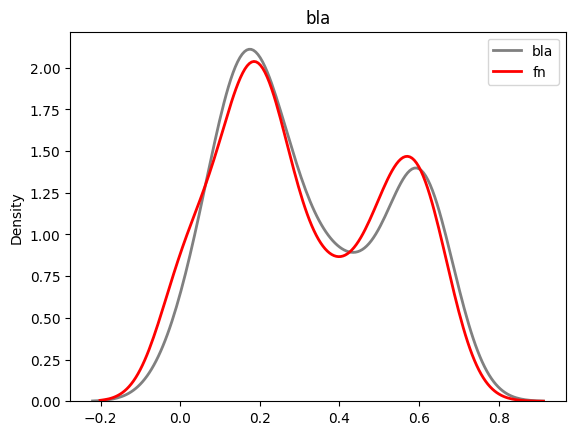

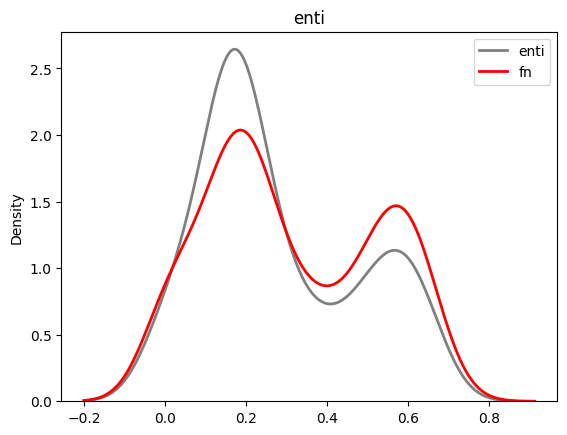

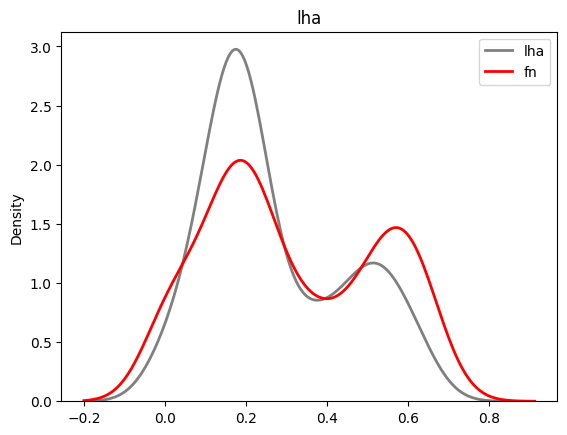

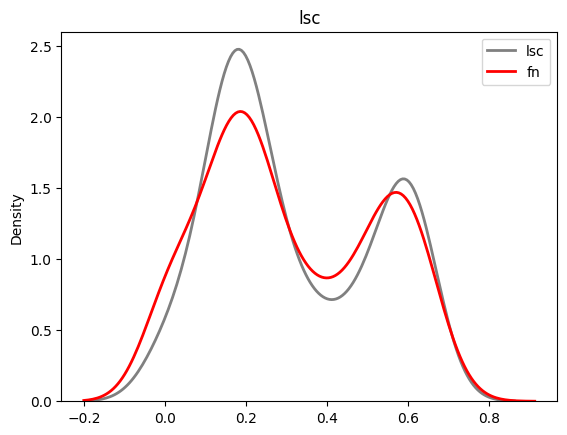

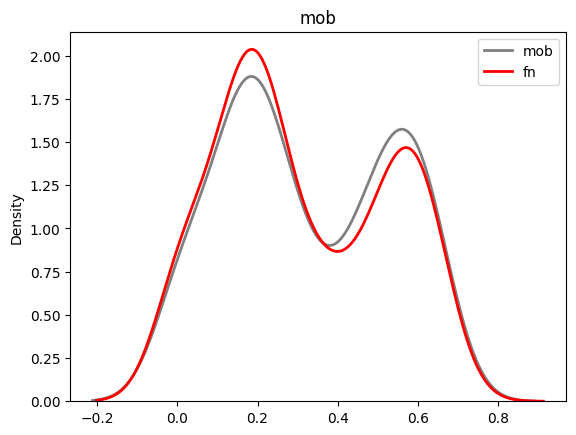

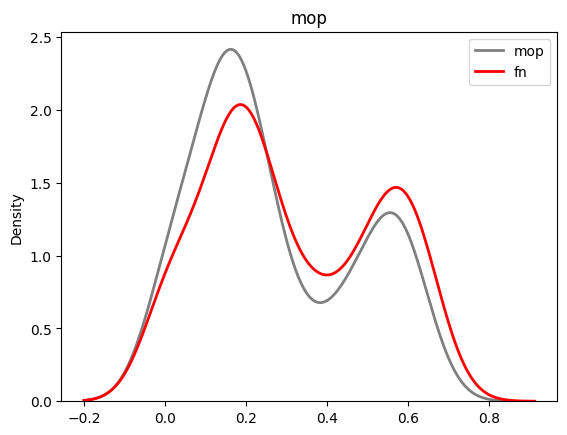

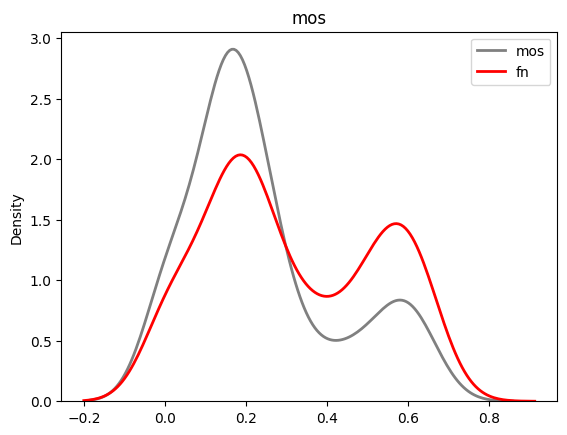

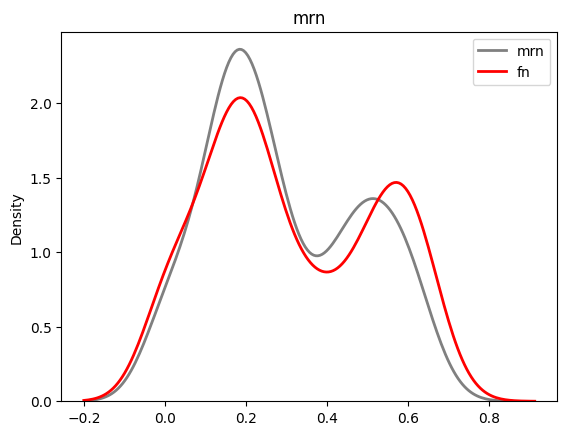

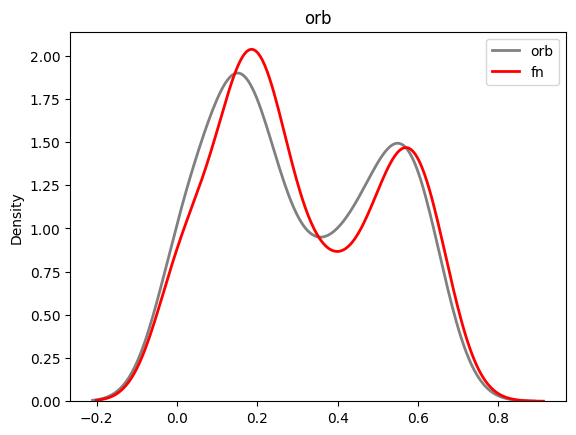

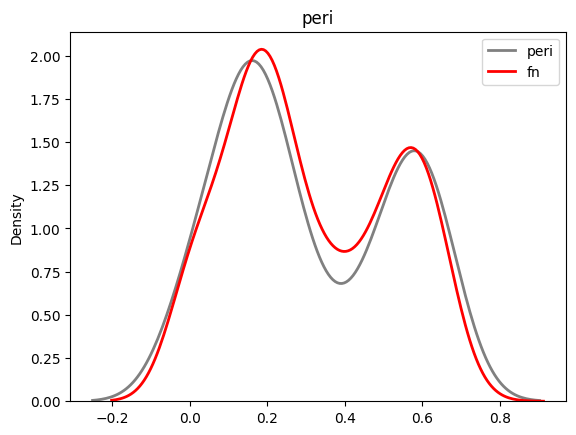

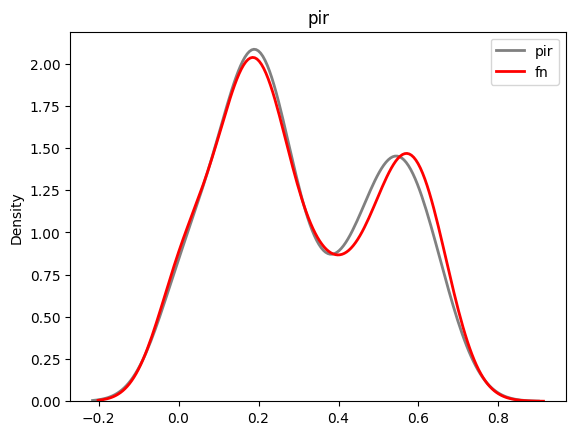

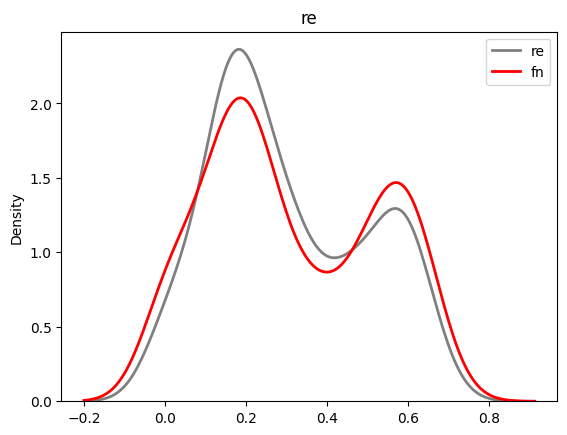

In [8]:
# getting  transition coverage data
import seaborn as sns

nw = ['bla', 'enti', 'lha', 'lsc', 'mob', 'mop', 'mos', 'mrn', 'orb', 'peri', 'pir', 're']

for i in nw:
	a_data=reader.data_read_pkl(f'results/calculate_final_params/final_{i}.pkl')
	a_fcov=a_data[2]['cov']
	a_pcov=a_data[1]['cov']
	a_pcov=[x for x in a_pcov if x>0]
	a_cov=a_fcov+a_pcov

	
	plt.figure()
	sns.kdeplot(a_cov,color='grey',linewidth=2,label=i)
	fn_data=reader.data_read_pkl('results/calculate_final_params/final_fn.pkl')
	fn_fcov=fn_data[2]['cov']
	fn_pcov=fn_data[1]['cov']
	fn_pcov=[x for x in fn_pcov if x>0]
	fn_cov=fn_fcov+fn_pcov
	sns.kdeplot(fn_cov,color='red',linewidth=2,label='fn')
	plt.title(i)
	plt.legend()
		




####  Take figure layout 

Text(0.05, 0.95, 'C')

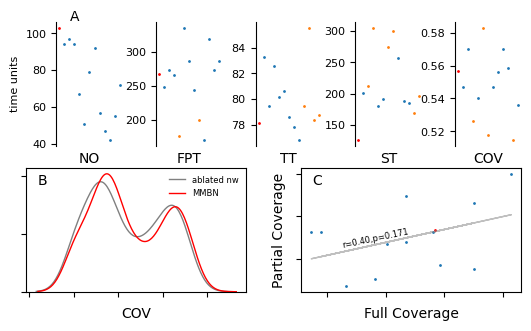

In [118]:
fig=plt.figure(figsize=(6,3.5))
gs=gridspec.GridSpec(10,14,wspace=2.5,hspace=3) #10 rows, 15 columns

# fig 3A
# make 5 plots inside 
sub_gs=gs[0:5,:].subgridspec(1,5,wspace=0.5)

# number of transitions
ax0=fig.add_subplot(sub_gs[0])
ax0.set_xticks([]) # hide tick labels
ax0.tick_params(axis='y',labelsize=8)
ax0.set_xlabel('NO')
ax0.set_ylabel('time units',fontsize=8)

ax0.scatter(np.arange(1,13),num_trans[1:],s=1)
ax0.scatter(0,num_trans[0],c='Red',s=1)



#FPT
ax1=fig.add_subplot(sub_gs[1])
ax1.set_xticks([])
ax1.tick_params(axis='y',labelsize=8)
ax1.set_xlabel('FPT')
# not significant networks
n_sg_fpt=list(set(list(range(1,13)))-set(f_m_s))
y_nsgfpt=[fpt_mean[x] for x in n_sg_fpt]
ax1.scatter(n_sg_fpt,y_nsgfpt,s=1)
# dark significant nw
y_fpt=[fpt_mean[x] for x in f_m_s ]
ax1.scatter(f_m_s,y_fpt,s=1)
#plot FN
ax1.scatter(0,fpt_mean[0],c='Red',s=1)



#TT
ax2=fig.add_subplot(sub_gs[2])
ax2.set_xticks([])
ax2.tick_params(axis='y',labelsize=8)
ax2.set_xlabel('TT')
# not significant networks
n_sg_tt=list(set(list(range(1,13)))-set(t_m_s))
y_nsgtt=[trans_time[x] for x in n_sg_tt]
ax2.scatter(n_sg_tt,y_nsgtt,s=1)
# dark significant nw
y_tt=[trans_time[x] for x in t_m_s ]
ax2.scatter(t_m_s,y_tt,s=1)
#plot FN
ax2.scatter(0,trans_time[0],c='Red',s=1)




#ST
ax3=fig.add_subplot(sub_gs[3])
ax3.set_xticks([])
ax3.tick_params(axis='y',labelsize=8)
ax3.set_xlabel('ST')
# not significant networks
n_sg_st=list(set(list(range(1,13)))-set(s_m_s))
y_nsgst=[st_mean[x] for x in n_sg_st]
ax3.scatter(n_sg_st,y_nsgst,s=1)
# dark significant nw
y_st=[st_mean[x] for x in s_m_s ]
ax3.scatter(s_m_s,y_st,s=1)
#plot FN
ax3.scatter(0,st_mean[0],c='Red',s=1)



#COV
ax4=fig.add_subplot(sub_gs[4])
ax4.set_xticks([])
ax4.tick_params(axis='y',labelsize=8)
ax4.set_xlabel('COV')
# not significant networks
n_sg_cv=list(set(list(range(1,13)))-set(c_m_s))
y_nsgcv=[cov[x] for x in n_sg_cv]
ax4.scatter(n_sg_cv,y_nsgcv,s=1)
# dark significant nw
y_cv=[cov[x] for x in c_m_s ]
ax4.scatter(c_m_s,y_cv,s=1)
#plot FN
ax4.scatter(0,cov[0],c='Red',s=1)


# hide spines
for ax in [ax0,ax1,ax2,ax3,ax4]:
	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)
	ax.spines['bottom'].set_visible(False)



#fig 3B
# plot coverage in comparison to FN
# choose network which looks cool
ax5=fig.add_subplot(gs[5:10,0:7])
ax5.set_yticklabels([])
ax5.set_xticklabels([])
ax5.set_xlabel("COV")
# shift this to left for more space
pos = ax5.get_position()
ax5.set_position([pos.x0-0.05,pos.y0,pos.width,pos.height])

# choosing ORB as it will look best
# combining coverage of both FN and ablated nw so that it looks bimodal
a_data=reader.data_read_pkl(f'results/calculate_final_params/final_orb.pkl')
a_fcov=a_data[2]['cov']
a_pcov=a_data[1]['cov']
a_pcov=[x for x in a_pcov if x>0]
a_cov=a_fcov+a_pcov
sns.kdeplot(a_cov,ax=ax5,color='grey',linewidth=1,label='ablated nw')
# read full network data
fn_data=reader.data_read_pkl('results/calculate_final_params/final_fn.pkl')
fn_fcov=fn_data[2]['cov']
fn_pcov=fn_data[1]['cov']
fn_pcov=[x for x in fn_pcov if x>0]
fn_cov=fn_fcov+fn_pcov
sns.kdeplot(fn_cov,ax=ax5,color='red',linewidth=1,label='MMBN')
ax5.legend(loc="upper right",fontsize=6,frameon=False)
ax5.set_ylabel("")




#fig 3C
# scatter plot of avg partial and full transition coverage
ax6=fig.add_subplot(gs[5:10,7:14])
ax6.set_yticklabels([])
ax6.set_xticklabels([])
ax6.set_xlabel("Full Coverage")
ax6.set_ylabel("Partial Coverage")
ax6.scatter(cov[1:],cov_part[1:],s=1)
ax6.scatter(cov[0],cov_part[0],c='Red',s=1)
# fit straight line
coeffs=np.polyfit(cov,cov_part,deg=1)
slope,intercept=coeffs
y_fit=slope*np.array(cov)+intercept
#pearson correlation
corr,pval =pearsonr(cov,cov_part)
#plot fit line
ax6.plot(cov,y_fit,color='grey',linewidth=1, alpha=0.5)
# annotate over line
x_mid=np.mean(cov)
y_mid=slope*x_mid+intercept-0.006
angle=np.degrees(np.arctan(slope))-5
ax6.text(x_mid,y_mid,f"r={corr:.2f},p={pval:.3f}",
		 fontsize=6,color='black', rotation=angle,
		 ha="right",va="bottom")


# Add subplot labels inside boxes
ax0.text(0.2, 1.1, "A",
         transform=ax0.transAxes,
        
         va="top", ha="left",
         )

ax5.text(0.05, 0.95, "B",
         transform=ax5.transAxes,
         
         va="top", ha="left"
        )

ax6.text(0.05, 0.95, "C",
         transform=ax6.transAxes,
         
         va="top", ha="left"
         )



Significant networks in comparision to FN

FPT

In [98]:
f_m_l

['pir', 'enti']

ST

In [90]:
s_m_l

['lsc', 'orb', 'mrn', 're', 'lha', 'mop']

COV

In [100]:
c_m_l

['orb', 'bla', 'mrn', 'lha']

Transition time

In [101]:

t_m_l

['peri', 'mos', 'lha', 'mop']

# Figure 4